In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT - temprature
# V = vaccum
# AP - pressure
# RH = humidity

# PE = produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE" , axis = 1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# split our data

from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state= 42
)

In [9]:
df.shape

(9568, 5)

In [10]:
# scaling the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


***
## convert data into pytorch tensors
***

In [11]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

# view(-1,1)
# view(rows, cols)

# -1 means take total no. of rows in original as rows in this array

# original y_train => (n,)
# after view(-1,1) => (n,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)


In [12]:
type(X_train_scaled)
# no need of .values since after scaling it is already converted into numpy array 

numpy.ndarray

In [13]:
type(y_train)

# since type is not an array 
# hence to convert it into tensor we explicitly use .values to get its values

pandas.core.series.Series

In [14]:
# ARCHITECTURE : 

        # HIDDEN LAYERS : 2
        # INPUT LAYER : 4 VALUES
        # NEURONS IN HIDDEN LAYERS : 6

***
## DataSet & DataLoader
***

In [15]:
# Tensor Dataset: accesses data from memory
                # define the dataset : one sample/one row
                                    # (features/targets)

# DataLader => interacts with tensor dataset to ask for data
            # => creates batches of our  data for ANN training
            # => defines how the data willl be loaded for training

In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,  y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)

***
## Building ANN Model
***

In [18]:
# defining the model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
    
            #nn.Linear(in_features , out_features)
            nn.Linear(X_train.shape[1] , 6),
    
            nn.ReLU(),
    
            # 2nd Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # OUTPUT LAYER
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [19]:
import torch.optim as optim

model = ANN()

# loss, optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


In [21]:
# Training ANN

train_losses  =[]
val_losses = []
epochs = 45

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb , yb in train_loader:
        #xb = features of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad() # set gradient to zero and start fresh

        outputs = model(xb) # predicted output for a particular batch
        loss = criterion(outputs, yb) # computr loss
        loss.backward() # backward propagation => compute gradients
        optimizer.step() # param update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    
    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs , yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss  / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f" {epoch+1}/{epochs} ==> train_loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict() , "best_model.pt") # .pt or .pth

 1/45 ==> train_loss = 192575.625 & val_loss = 176985.0
 2/45 ==> train_loss = 152191.89212239583 & val_loss = 123715.984375
 3/45 ==> train_loss = 95590.78610026042 & val_loss = 69961.328125
 4/45 ==> train_loss = 53115.00100097656 & val_loss = 39374.453125
 5/45 ==> train_loss = 31409.764713541666 & val_loss = 24679.78515625
 6/45 ==> train_loss = 20995.55088297526 & val_loss = 17529.103515625
 7/45 ==> train_loss = 15444.781880696615 & val_loss = 13153.2529296875
 8/45 ==> train_loss = 11566.380684407552 & val_loss = 9654.814453125
 9/45 ==> train_loss = 8343.769880167643 & val_loss = 6782.7783203125
 10/45 ==> train_loss = 5823.330935668945 & val_loss = 4653.4970703125
 11/45 ==> train_loss = 4054.4176025390625 & val_loss = 3285.301513671875
 12/45 ==> train_loss = 2956.566325887044 & val_loss = 2463.310302734375
 13/45 ==> train_loss = 2275.297914123535 & val_loss = 1925.356689453125
 14/45 ==> train_loss = 1801.730029296875 & val_loss = 1530.542724609375
 15/45 ==> train_loss = 1

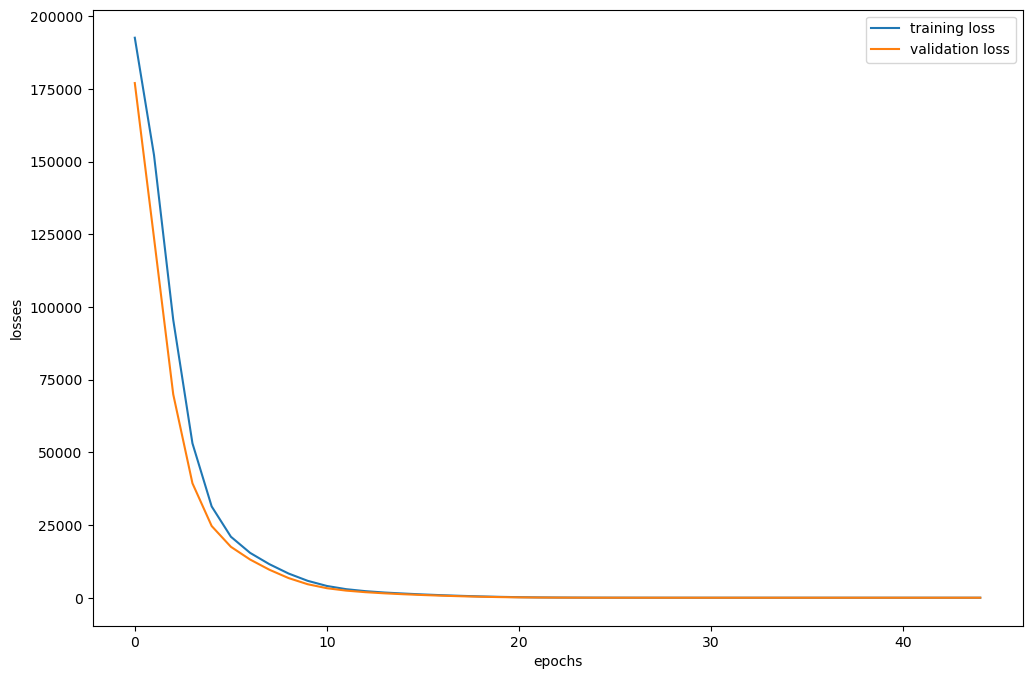

In [22]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss":val_losses
})
plt.figure(figsize=(12,8))

plt.plot(loss_df["train_loss"], label = "training loss")
plt.plot(loss_df["val_loss"], label = "validation loss")

plt.xlabel("epochs")
plt.ylabel("losses")

plt.legend()

***
## Saving anf Loading Best Model
***

In [23]:
# aim - minimize validation loss  => since model has not seen this data
# model has already seen training data multiple times and so it will adjust weights accordingly to minimize this loss

In [24]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

***
### Evaluation
***

In [26]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds , y_test_tensor)

print("training mse : ", train_mse_loss.item())
print("testing mse : ", test_mse_loss.item())

training mse :  20.48193359375
testing mse :  18.78662109375


In [27]:
from sklearn.metrics import r2_score as r2

print("r2_score : ", r2(y_test, test_preds))

r2_score :  0.9343456090852931


In [29]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df , actual_df] , axis = 1)

,Predicted Values,Actual Values
0,435.232452,433.27
1,437.139069,438.16
2,461.062592,458.42
3,476.147217,480.82
4,435.043518,441.41
...,...,...
1909,451.527374,456.70
1910,431.740936,438.04
1911,467.474976,467.80
1912,431.180450,437.14
